# Ridge and Lasso Regression

#### Are regularization techniques used for Linear Regression (more in linear_regression.ipynb) to prevent overfitting by penalizing large coefficients.

#### Ridge Regression adds sum of squared coefficients (L2 penalty).

#### Lasso Regression adds sum of absolute values of coefficients (L1 penalty) which can lead to feature selection by shrinking some coefficients to zero.

## Ridge Regression (L2)

#### Adds penalty as a $\textbf{sum of squared weights}$:

$$
J(\omega,b)=\frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)}-y^{(i)})^2+\lambda\sum_{j=1}^{n}\omega_n^2
$$

#### $\lambda$ - regularization coefficient (the bigger it is, the greater the penalty for large weights).

#### Weights are reduced, but never zeroed.

#### Great for use, when all features are important, but you only want them to be reduced.

## Lasso Regression (L1)

#### Adds penalty as a $\textbf{sum of absolute values of weights}$:

$$
J(\omega,b)=\frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)}-y^{(i)})^2+\lambda\sum_{j=1}^{n}\left| \omega_n\right|
$$

#### Reduces weights to zero, works as an automatic $\textbf{feature selector}$.

#### Great for use, when you want to eliminate some less relevant features.

## Dataset

#### Advertising Dataset from Kaggle has been used as a dataset for this example mini-project, which contains correlations between advertisement on various media like TV, Radio or Newspaper and Sales. Correlation between TV Advertisement and Sales has been used for this mini-project because of his nearly perfect linearity.

#### https://www.kaggle.com/datasets/ashydv/advertising-dataset

## 1. Import necessary libraries

In [22]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 2. Load and visualize dataset

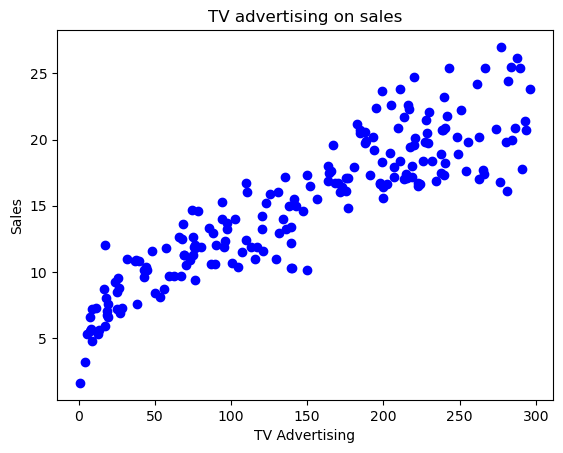

In [23]:
df = pd.read_csv('data/advertising.csv', usecols=[0, 3])
plt.scatter(df['TV'], df['Sales'], color='blue')
plt.title('TV advertising on sales')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.show()

## 3. Split the data into training and testing sets

In [24]:
X = df['TV'].to_numpy().reshape(-1, 1)
y = df['Sales'].to_numpy().reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Initialize and train the Ridge and Lasso models

In [25]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.1)

## 5. Make predictions and evaluate models

In [26]:
ridge_pred = ridge_model.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)

lasso_pred = lasso_model.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print('Ridge Mean Squared Error:', ridge_mse)
print('Lasso Mean Squared Error:', lasso_mse)

Ridge Mean Squared Error: 6.101072892488206
Lasso Mean Squared Error: 6.101070453468011


## 7. Visualize Ridge predictions

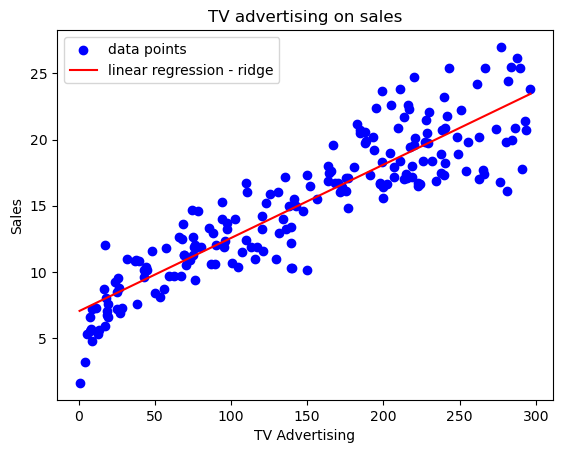

In [27]:
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = ridge_model.predict(X_plot)

plt.scatter(df['TV'], df['Sales'], color='blue', label='data points')
plt.plot(X_plot, y_plot, color='red', label='linear regression - ridge')
plt.title('TV advertising on sales')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.legend()
plt.show()

## 8. Visualize Lasso predictions

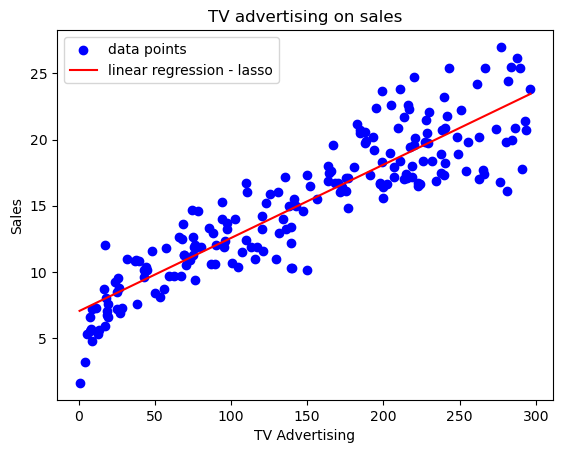

In [28]:
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = lasso_model.predict(X_plot)

plt.scatter(df['TV'], df['Sales'], color='blue', label='data points')
plt.plot(X_plot, y_plot, color='red', label='linear regression - lasso')
plt.title('TV advertising on sales')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.legend()
plt.show()